In [ ]:
#FOREX - Old
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

pairs = [
    'EURUSD=X','GBPUSD=X','CHFUSD=X','CADUSD=X','SEKUSD=X',
    'JPYUSD=X','AUDUSD=X','CNYUSD=X','SGDUSD=X','HKDUSD=X',
    'KRWUSD=X','BRLUSD=X','ARSUSD=X','CLPUSD=X','MXNUSD=X',
    'ZARUSD=X'
]

# período alvo: 2024-09-30 até 2025-09-30
start_download = '2024-09-01'             # margem antes de 2024-09-30
end_download = '2025-10-01'               # yfinance: use end = target + 1 day para garantir inclusão

# períodos trimestrais usados no relatório
start_jul25 = '2025-07-01'
end_sep25 = '2025-09-30'
end_sep24 = '2024-09-30'                   # CORREÇÃO: usar dia 30

raw = yf.download(pairs, start=start_download, end=end_download, group_by='ticker', auto_adjust=False)

# raw geralmente tem MultiIndex columns; usar raw['Close'] que é DataFrame com colunas = tickers
closes = raw['Close']

def last_available_close(series, target_date):
    """Retorna o último fechamento disponível em series com índice DatetimeIndex <= target_date."""
    target = pd.to_datetime(target_date)
    # se target presente, retorna; caso contrário, pega último índice anterior
    if target in series.index:
        return series.loc[target]
    else:
        prev = series.loc[:target]
        if prev.empty:
            return np.nan
        return prev.iloc[-1]

# fechar de referência em 30/09/2024 (última sessão <= 2024-09-30)
close_last_year = last_available_close(closes, end_sep24)

# consolidar OPEN/HIGH/LOW/CLOSE para o período 2025-07-01 .. 2025-09-30
opens = raw['Open']
highs = raw['High']
lows  = raw['Low']

# obter primeiro/último sessão disponível dentro do intervalo desejado
start_idx = opens.index[opens.index >= pd.to_datetime(start_jul25)][0]
end_idx = closes.index[closes.index <= pd.to_datetime(end_sep25)][-1]

open_series  = opens.loc[start_idx]
high_series  = highs.loc[start_jul25:end_sep25].max()
low_series   = lows.loc[start_jul25:end_sep25].min()
close_series = closes.loc[end_idx]

df = pd.DataFrame({
    'OPEN': open_series,
    'HIGH': high_series,
    'LOW': low_series,
    'CLOSE': close_series,
})

# cálculos financeiros (QTD / YTD)
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100
df['YTD'] = df['CLOSE'] - close_last_year.values
df['YTD(%)'] = df['YTD'] / close_last_year.values * 100

df.index.name = 'Currency'
df = df[['OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)']]

print(df)
df.reset_index().to_excel("forex_jul_sep_2025.xlsx", index=False)
print("Planilha gerada com sucesso: forex_jul_sep_2025.xlsx")

C:\Users\henri\AppData\Local\Temp\ipykernel_31276\1916807603.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(pairs, start=start_full, end=end_full, progress=True)
[*********************100%***********************]  16 of 16 completed

Planilha salva em: forex_jul_sep_2025.xlsx


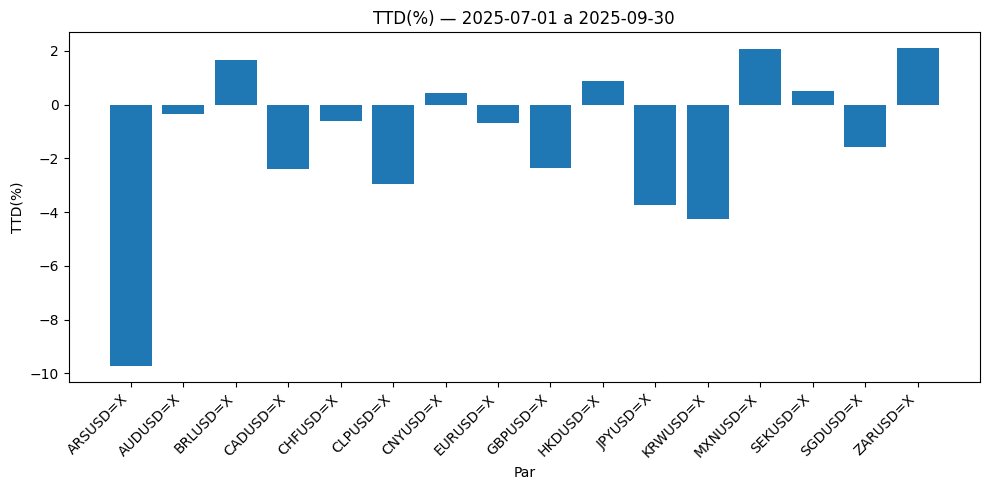

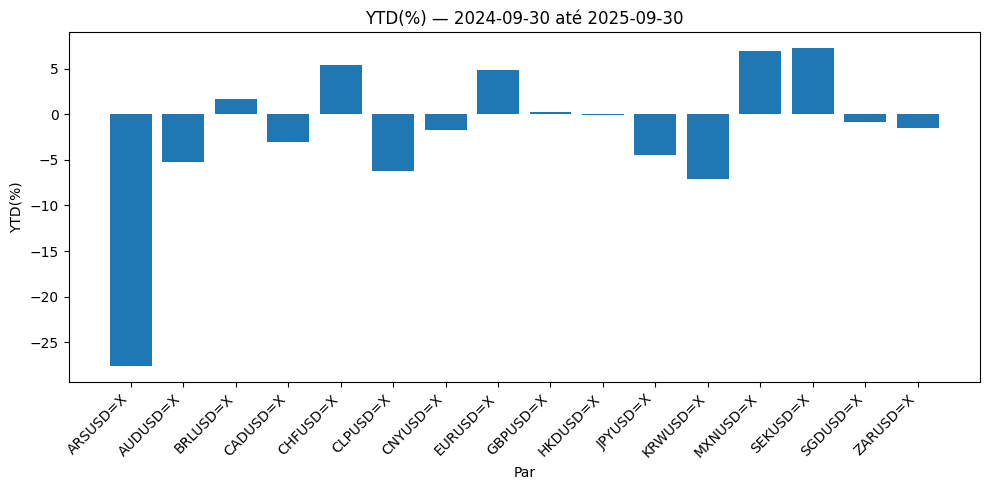

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pairs = [
 'EURUSD=X','GBPUSD=X','CHFUSD=X','CADUSD=X','SEKUSD=X',
 'JPYUSD=X','AUDUSD=X','CNYUSD=X','SGDUSD=X','HKDUSD=X',
 'KRWUSD=X','BRLUSD=X','ARSUSD=X','CLPUSD=X','MXNUSD=X',
 'ZARUSD=X'
]

# Timeframes
start_jul25 = '2025-07-01'
end_sep25 = '2025-09-30'
start_full = '2024-09-01'   
end_full = '2025-09-30'
end_sep24 = '2024-09-30'    

# Baixa dados
raw = yf.download(pairs, start=start_full, end=end_full, progress=True)

# Separar Open/High/Low/Close adequadamente
if isinstance(raw.columns, pd.MultiIndex):
    open_df = raw['Open']
    high_df = raw['High']
    low_df  = raw['Low']
    close_df= raw['Close']
else:
    # fallback (pouco provável)
    open_df = raw['Open']
    high_df = raw['High']
    low_df  = raw['Low']
    close_df= raw['Close']

# Funções para pegar primeiro disponível >= data e último disponível <= data
def first_available(series_df, date_str):
    s = series_df.loc[date_str:]
    return s.iloc[0]

def last_available(series_df, date_str):
    s = series_df.loc[:date_str]
    return s.iloc[-1]

open_on_start = first_available(open_df, start_jul25)
high_in_range = high_df.loc[start_jul25:end_sep25].max()
low_in_range  = low_df.loc[start_jul25:end_sep25].min()
close_on_end  = last_available(close_df, end_sep25)
close_last_year= last_available(close_df, end_sep24)

# Montar DataFrame
df = pd.DataFrame({
    'Ticker': open_on_start.index,
    'OPEN': open_on_start.values,
    'HIGH': high_in_range.values,
    'LOW': low_in_range.values,
    'CLOSE': close_on_end.values,
    'CLOSE_2024-09-30': close_last_year.values
})

# Cálculos
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100
df['YTD'] = df['CLOSE'] - df['CLOSE_2024-09-30']
df['YTD(%)'] = df['YTD'] / df['CLOSE_2024-09-30'] * 100

# Formatação
df[['OPEN','HIGH','LOW','CLOSE','CLOSE_2024-09-30']] = df[['OPEN','HIGH','LOW','CLOSE','CLOSE_2024-09-30']].round(6)
df[['TTD','TTD(%)','YTD','YTD(%)']] = df[['TTD','TTD(%)','YTD','YTD(%)']].round({'TTD':6,'TTD(%)':2,'YTD':6,'YTD(%)':2})

# Reorder / salvar
df = df[['Ticker','OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)','CLOSE_2024-09-30']]
out_path = 'forex_jul_sep_2025.xlsx'
df.to_excel(out_path, index=False)
print(f"Planilha salva em: {out_path}")

# Plots
plt.figure(figsize=(10,5))
plt.title("TTD(%) — 2025-07-01 a 2025-09-30")
plt.bar(df['Ticker'], df['TTD(%)'])
plt.ylabel("TTD(%)")
plt.xlabel("Par")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.title("YTD(%) — 2024-09-30 até 2025-09-30")
plt.bar(df['Ticker'], df['YTD(%)'])
plt.ylabel("YTD(%)")
plt.xlabel("Par")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Markets

import yfinance as yf
import pandas as pd

markets_list = [
   '^GSPC', '^IXIC', '^DJI',
   '^FTSE', '^GDAXI','^N100',
   '^N225', '^HSI', '^NSEI', '^TWII', '^STI', '^KS11',
   '^BVSP', '^MXX', '^MERV'
]

# Timeframes
start_ = '2025-07-01'
end_ = '2025-09-30'
ref_date_last_year = '2024-07-01'

raw = yf.download(markets_list, start='2024-07-01', end='2025-10-01')

# raw has MultiIndex columns, eg: ('Open', '^GSPC')
# Lets simplify:

# Select data
sep_data = raw.loc[start_:end_]

df = pd.DataFrame({
     'OPEN': sep_data['Open'].iloc[0],
    'HIGH': sep_data['High'].max(),
    'LOW': sep_data['Low'].min(),
    'CLOSE': sep_data['Close'].iloc[-1],
})

# Financial calculus
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100

#Last year data
close_last_year = raw['Close'].loc[ref_date_last_year]
df['YTD'] = df['CLOSE'] - close_last_year.values
df['YTD(%)'] = df['YTD'] / close_last_year.values * 100

df = df[['OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)']]

print(df)


df.to_excel("markets.xlsx", index=False)
print("Planilha gerada com sucesso: markets.xlsx")

C:\Users\henri\AppData\Local\Temp\ipykernel_31276\1454493796.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(markets_jul_sep_2025, start='2024-07-01', end='2025-10-01')
[*********************100%***********************]  15 of 15 completed

                OPEN         CLOSE          HIGH           LOW            TTD  \
Ticker                                                                          
^BVSP   1.388550e+05  1.462370e+05  1.475780e+05  1.315500e+05    7382.000000   
^DJI    4.406149e+04  4.639789e+04  4.671427e+04  4.334068e+04    2336.402344   
^FTSE   8.761000e+03  9.350400e+03  9.363600e+03  8.726900e+03     589.400391   
^GDAXI  2.396695e+04  2.388072e+04  2.463910e+04  2.328467e+04     -86.228516   
^GSPC   6.187250e+03  6.688460e+03  6.699520e+03  6.177970e+03     501.209961   
^HSI             NaN  2.685556e+04  2.705803e+04  2.369094e+04            NaN   
^IXIC   2.029061e+04  2.266001e+04  2.280190e+04  2.010541e+04    2369.400391   
^KS11   3.089640e+03  3.424600e+03  3.497950e+03  3.032470e+03     334.960205   
^MERV   1.994825e+06  1.773440e+06  2.437283e+06  1.635451e+06 -221385.000000   
^MXX    5.744631e+04  6.291557e+04  6.312853e+04  5.528790e+04    5469.261719   
^N100   1.568910e+03  1.6585

Baixando dados (pode demorar)...


C:\Users\henri\AppData\Local\Temp\ipykernel_31276\4088587284.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(markets, start=full_start, end=full_end, progress=True)
[*********************100%***********************]  15 of 15 completed


               OPEN        CLOSE         HIGH          LOW         TTD  \
Ticker                                                                   
^GSPC      6187.250     6661.210     6699.520     6177.970     473.960   
^IXIC     20290.609    22591.150    22801.900    20105.410    2300.541   
^DJI      44061.488    46316.070    46714.270    43340.680    2254.582   
^FTSE      8761.000     9299.800     9357.500     8726.900     538.800   
^GDAXI    23966.949    23745.061    24639.100    23284.670    -221.889   
^N100      1568.910     1655.770     1658.930     1534.950      86.860   
^N225     40340.641    45043.750    45852.750    39288.898    4703.109   
^HSI      24304.311    26622.881    27058.029    23690.939    2318.570   
^NSEI     25551.350    24634.900    25608.100    24337.500    -916.449   
^TWII     22419.740    25580.320    26394.029    22190.461    3160.580   
^STI       3972.180     4269.980     4375.330     3968.570     297.800   
^KS11      3089.640     3431.210     3

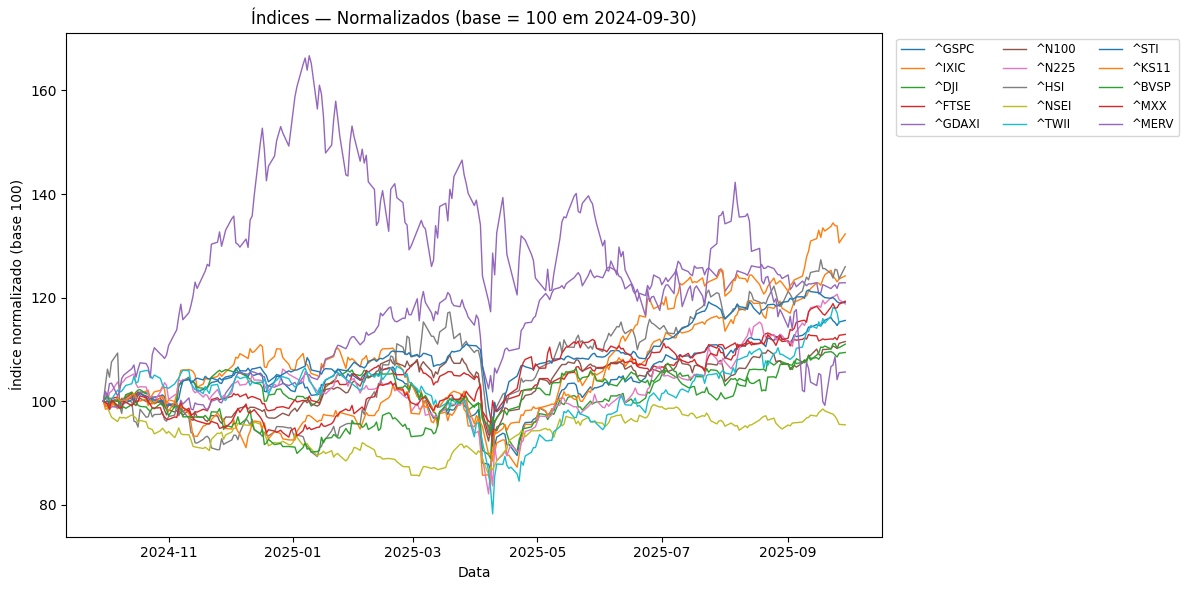

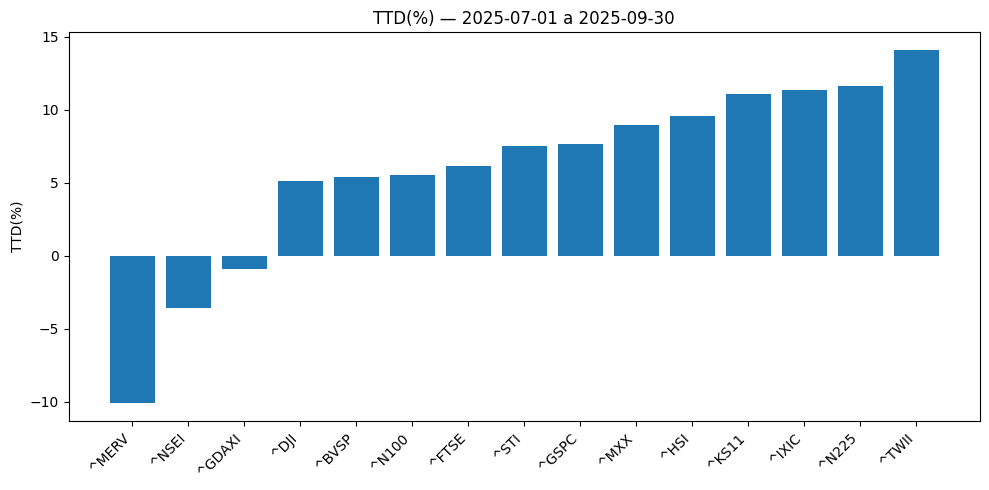

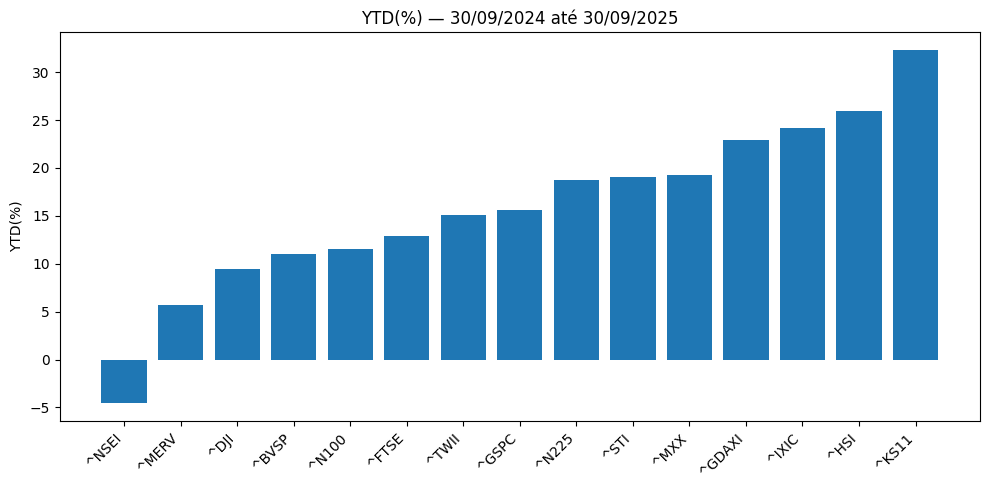

In [1]:
#Markets V2
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

markets = [
   '^GSPC', '^IXIC', '^DJI',
   '^FTSE', '^GDAXI','^N100',
   '^N225', '^HSI', '^NSEI', '^TWII', '^STI', '^KS11',
   '^BVSP', '^MXX', '^MERV'
]

# Períodos
period_start = '2025-07-01'    
period_end   = '2025-09-30'      
y_ref_date   = '2024-09-30'      
full_start   = '2024-09-01'      
full_end     = '2025-09-30'      

print("Baixando dados (pode demorar)...")
raw = yf.download(markets, start=full_start, end=full_end, progress=True)

if isinstance(raw.columns, pd.MultiIndex):
    open_df  = raw['Open']
    high_df  = raw['High']
    low_df   = raw['Low']
    close_df = raw['Close']
else:
    # fallback (improvável): raw has single-level columns
    open_df  = raw['Open'] if 'Open' in raw.columns else pd.DataFrame()
    high_df  = raw['High'] if 'High' in raw.columns else pd.DataFrame()
    low_df   = raw['Low'] if 'Low' in raw.columns else pd.DataFrame()
    close_df = raw['Close'] if 'Close' in raw.columns else pd.DataFrame()

def safe_first_available(series, date_str):
    try:
        s = series.loc[date_str:]
        if s.dropna().empty:
            return np.nan
        return s.dropna().iloc[0]
    except Exception:
        return np.nan

def safe_last_available(series, date_str):
    try:
        s = series.loc[:date_str]
        if s.dropna().empty:
            return np.nan
        return s.dropna().iloc[-1]
    except Exception:
        return np.nan

def try_re_download(ticker):
    try:
        sub = yf.download(ticker, start=full_start, end=full_end, progress=False)
        if sub is None or sub.empty:
            return None
        return sub
    except Exception:
        return None

rows = []

for t in markets:
    # Se ticker presente nas colunas baixadas
    if t in open_df.columns and t in close_df.columns:
        o = safe_first_available(open_df[t], period_start)
        h = high_df[t].loc[period_start:period_end].max() if (t in high_df.columns) else np.nan
        l = low_df[t].loc[period_start:period_end].min()  if (t in low_df.columns) else np.nan
        c = safe_last_available(close_df[t], period_end)
        c_ly = safe_last_available(close_df[t], y_ref_date)
    else:
        sub = try_re_download(t)
        if sub is not None and not sub.empty:
            try:
                o = safe_first_available(sub['Open'], period_start)
                h = sub['High'].loc[period_start:period_end].max()
                l = sub['Low'].loc[period_start:period_end].min()
                c = safe_last_available(sub['Close'], period_end)
                c_ly = safe_last_available(sub['Close'], y_ref_date)
            except Exception:
                o = h = l = c = c_ly = np.nan
        else:
            # não conseguiu obter dados -> marca NaN e segue
            print(f"Warning: dados não encontrados para {t}. Marcando como NaN.")
            o = h = l = c = c_ly = np.nan

    rows.append({
        'Ticker': t,
        'OPEN': o, 'HIGH': h, 'LOW': l, 'CLOSE': c,
        'CLOSE_2024-09-30': c_ly
    })

df = pd.DataFrame(rows).set_index('Ticker')

# Cálculos financeiros
df['TTD'] = df['CLOSE'] - df['OPEN']
df['TTD(%)'] = df['TTD'] / df['OPEN'] * 100
df['YTD'] = df['CLOSE'] - df['CLOSE_2024-09-30']
df['YTD(%)'] = df['YTD'] / df['CLOSE_2024-09-30'] * 100

df[['OPEN','HIGH','LOW','CLOSE','CLOSE_2024-09-30']] = df[['OPEN','HIGH','LOW','CLOSE','CLOSE_2024-09-30']].round(3)
df[['TTD','TTD(%)','YTD','YTD(%)']] = df[['TTD','TTD(%)','YTD','YTD(%)']].round(3)

df_out = df[['OPEN','CLOSE','HIGH','LOW','TTD','TTD(%)','YTD','YTD(%)','CLOSE_2024-09-30']]
print(df_out)

# Salvar Excel
out_file = "markets_sep_2025.xlsx"
df_out.to_excel(out_file, index=True)
print(f"Planilha salva como: {out_file}")

# Gráficos
plt.figure(figsize=(12,6))
for t in markets:
    # obter série de fechamento
    if t in close_df.columns:
        series = close_df[t].loc[y_ref_date:full_end].dropna()
    else:
        sub = try_re_download(t)
        series = sub['Close'].loc[y_ref_date:full_end].dropna() if sub is not None else pd.Series(dtype=float)
    if series.empty:
        continue
    base = safe_last_available(series, y_ref_date)
    if pd.isna(base) or base == 0:
        continue
    norm = series / base * 100
    plt.plot(norm.index, norm.values, label=t, linewidth=1)

plt.title("Índices — Normalizados Year Over Year")
plt.ylabel("Índice normalizado (base 100)")
plt.xlabel("Data")
plt.legend(ncol=3, fontsize='small', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
valid_ttd = df_out['TTD(%)'].replace([np.inf, -np.inf], np.nan).dropna()
valid_ttd.sort_values(inplace=True)
plt.bar(valid_ttd.index, valid_ttd.values)
plt.title("TTD(%) — 2025-07-01 a 2025-09-30")
plt.ylabel("TTD(%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
valid_ytd = df_out['YTD(%)'].replace([np.inf, -np.inf], np.nan).dropna()
valid_ytd.sort_values(inplace=True)
plt.bar(valid_ytd.index, valid_ytd.values)
plt.title("YTD(%) — 30/09/2024 até 30/09/2025")
plt.ylabel("YTD(%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [3]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np

# Pares de moedas principais
pairs = [
    'EURUSD=X', 'GBPUSD=X', 'CHFUSD=X', 'CADUSD=X', 'SEKUSD=X',
    'JPYUSD=X', 'AUDUSD=X', 'CNYUSD=X', 'SGDUSD=X', 'HKDUSD=X',
    'KRWUSD=X', 'BRLUSD=X', 'ARSUSD=X', 'CLPUSD=X', 'MXNUSD=X',
    'ZARUSD=X'
]

def get_monthly_ohlc_data(pairs, target_month='2025-07'):
    """
    Coleta dados OHLC mensais consolidados para o mês especificado
    """

    # Definir período para coleta (mês inteiro + dados YTD)
    start_jul_2025 = f'{target_month}-01'
    end_jul_2025 = f'{target_month}-31'

    # Para cálculo YTD - junho do ano anterior
    start_jul_2024 = '2024-07-01'
    end_jul_2024 = '2024-07-31'

    # Para cálculo da variação mensal - maio 2025
    start_jun_2025 = '2025-06-02'
    end_jun_2025 = '2025-06-30'

    results = []

    for pair in pairs:
        try:
            currency_name = pair.replace('=X', '').replace('USD', '')

            # Coleta dados junho 2025
            data_jul_2025 = yf.download(pair, start=start_jul_2025, end=end_jul_2025, interval='1d')

            # Coleta dados maio 2025 (para variação mensal)
            data_jun_2025 = yf.download(pair, start=start_jun_2025, end=end_jun_2025, interval='1d')

            # Coleta dados junho 2024 (para YTD)
            data_jul_2024 = yf.download(pair, start=start_jul_2024, end=end_jul_2024, interval='1d')

            if data_jul_2025.empty:
                print(f"❌ {currency_name}: Sem dados para julho 2025")
                continue

            # Consolidação mensal - junho 2025
            monthly_open = float(data_jul_2025['Open'].iloc[0])
            monthly_high = float(data_jul_2025['High'].max())
            monthly_low = float(data_jul_2025['Low'].min())
            monthly_close = float(data_jul_2025['Close'].iloc[-1])

            # Variação mensal (maio vs junho 2025)
            monthly_variation = 0.0
            monthly_variation_pct = 0.0

            if not data_jun_2025.empty:
                jun_close = float(data_jun_2025['Close'].iloc[-1])
                monthly_variation = monthly_close - jun_close
                monthly_variation_pct = (monthly_variation / jun_close) * 100

            # Variação YTD (junho 2024 vs junho 2025)
            ytd_variation = 0.0
            ytd_variation_pct = 0.0
            jul_2024_close = None

            if not data_jul_2024.empty:
                jul_2024_close = float(data_jul_2024['Close'].iloc[-1])
                ytd_variation = monthly_close - jul_2024_close
                ytd_variation_pct = (ytd_variation / jul_2024_close) * 100

            # Compilar resultado com validação de tipos
            result = {
                'Currency': str(currency_name),
                'Open_jul2025': round(monthly_open, 5),
                'High_jul2025': round(monthly_high, 5),
                'Low_jul2025': round(monthly_low, 5),
                'Close_jul2025': round(monthly_close, 5),
                'Monthly_Variation': round(monthly_variation, 5),
                'Monthly_Variation_Pct': round(monthly_variation_pct, 3),
                'YTD_Variation': round(ytd_variation, 5),
                'YTD_Variation_Pct': round(ytd_variation_pct, 3),
                'Close_jul2024': round(jul_2024_close, 5) if jul_2024_close is not None else np.nan
            }

            results.append(result)
            print(f"✅ {currency_name}: Dados consolidados coletados")

        except Exception as e:
            print(f"❌ {pair}: Erro - {str(e)}")
            continue

    return pd.DataFrame(results)

# Executar coleta
print("🔄 Coletando dados mensais consolidados...")
df_monthly = get_monthly_ohlc_data(pairs)

if not df_monthly.empty:
    # CORREÇÃO: Validação robusta antes da ordenação
    print(f"📊 Dados coletados: {len(df_monthly)} moedas")

    # Verificar tipos de dados
    print("\n🔍 Verificando tipos de dados:")
    print(df_monthly.dtypes)

    # Limpeza de dados: remover linhas com valores críticos faltantes
    df_monthly_clean = df_monthly.dropna(subset=['YTD_Variation_Pct', 'Monthly_Variation_Pct'])

    # Garantir que colunas numéricas sejam do tipo correto
    numeric_columns = ['Open_jul2025', 'High_jul2025', 'Low_jul2025', 'Close_jul2025',
                      'Monthly_Variation', 'Monthly_Variation_Pct', 'YTD_Variation', 'YTD_Variation_Pct']

    for col in numeric_columns:
        if col in df_monthly_clean.columns:
            df_monthly_clean[col] = pd.to_numeric(df_monthly_clean[col], errors='coerce')

    # Remover linhas com valores inválidos após conversão
    df_monthly_clean = df_monthly_clean.dropna(subset=['YTD_Variation_Pct'])

    # Reset do índice para evitar problemas de alinhamento
    df_monthly_clean = df_monthly_clean.reset_index(drop=True)

    # Ordenar por variação YTD decrescente (AGORA SEM ERRO)
    df_monthly_sorted = df_monthly_clean.sort_values('YTD_Variation_Pct', ascending=False)

    print(f"✅ Dados limpos: {len(df_monthly_sorted)} moedas válidas")

    # Salvar em Excel
    try:
        with pd.ExcelWriter('forex_monthly_jul2025.xlsx', engine='openpyxl') as writer:
            df_monthly_sorted.to_excel(writer, sheet_name='Monthly_Data', index=False)

        print("💾 Arquivo salvo: forex_monthly_jul2025.xlsx")
    except Exception as e:
        print(f"⚠️ Erro ao salvar Excel: {e}")
        # Salvar como CSV como alternativa
        df_monthly_sorted.to_csv('forex_monthly_jul2025.csv', index=False)
        print("💾 Arquivo salvo como CSV: forex_monthly_jul2025.csv")

    # Exibir tabela resumo
    if not df_monthly_sorted.empty:
        print("\n📈 Top 5 Moedas por Performance YTD:")
        display_cols = ['Currency', 'Close_jul2025', 'Monthly_Variation_Pct', 'YTD_Variation_Pct']
        print(df_monthly_sorted[display_cols].head().to_string(index=False))

        # Estatísticas descritivas
        print(f"\n📊 Estatísticas Resumo:")
        print(f"Variação Mensal Média: {df_monthly_sorted['Monthly_Variation_Pct'].mean():.3f}%")
        print(f"Variação YTD Média: {df_monthly_sorted['YTD_Variation_Pct'].mean():.3f}%")
        print(f"Maior Variação YTD: {df_monthly_sorted['YTD_Variation_Pct'].max():.3f}% ({df_monthly_sorted.iloc[0]['Currency']})")
        print(f"Menor Variação YTD: {df_monthly_sorted['YTD_Variation_Pct'].min():.3f}% ({df_monthly_sorted.iloc[-1]['Currency']})")

else:
    print("❌ Nenhum dado foi coletado com sucesso.")

C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jul_2025 = yf.download(pair, start=start_jul_2025, end=end_jul_2025, interval='1d')
[*********************100%***********************]  1 of 1 completed

🔄 Coletando dados mensais consolidados...



C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jun_2025 = yf.download(pair, start=start_jun_2025, end=end_jun_2025, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jul_2024 = yf.download(pair, start=start_jul_2024, end=end_jul_2024, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monthly_open = float(data_jul_2025['Open'].iloc[0])
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:52: FutureWarning: Calling float on a single element Series is

✅ EUR: Dados consolidados coletados


[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jul_2024 = yf.download(pair, start=start_jul_2024, end=end_jul_2024, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monthly_open = float(data_jul_2025['Open'].iloc[0])
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:52: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monthly_high = float(data_jul_2025['High'].max())
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:53: FutureWarning: Calling float on a

...

✅ CLP: Dados consolidados coletados


[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jun_2025 = yf.download(pair, start=start_jun_2025, end=end_jun_2025, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jul_2024 = yf.download(pair, start=start_jul_2024, end=end_jul_2024, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monthly_open = float(data_jul_2025['Open'].iloc[0])
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\21420603

✅ MXN: Dados consolidados coletados


[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jun_2025 = yf.download(pair, start=start_jun_2025, end=end_jun_2025, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_jul_2024 = yf.download(pair, start=start_jul_2024, end=end_jul_2024, interval='1d')
[*********************100%***********************]  1 of 1 completed
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\2142060304.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  monthly_open = float(data_jul_2025['Open'].iloc[0])
C:\Users\henri\AppData\Local\Temp\ipykernel_7808\21420603

✅ ZAR: Dados consolidados coletados
📊 Dados coletados: 16 moedas

🔍 Verificando tipos de dados:
Currency                  object
Open_jul2025             float64
High_jul2025             float64
Low_jul2025              float64
Close_jul2025            float64
Monthly_Variation        float64
Monthly_Variation_Pct    float64
YTD_Variation            float64
YTD_Variation_Pct        float64
Close_jul2024            float64
dtype: object
✅ Dados limpos: 16 moedas válidas
💾 Arquivo salvo: forex_monthly_jul2025.xlsx

📈 Top 5 Moedas por Performance YTD:
Currency  Close_jul2025  Monthly_Variation_Pct  YTD_Variation_Pct
     SEK        0.10364                 -1.455             12.246
     CHF        1.24151                 -0.569             10.010
     EUR        1.15509                 -1.208              6.761
     SGD        0.77664                 -0.956              4.304
     GBP        1.33536                 -2.704              3.835

📊 Estatísticas Resumo:
Variação Mensal Média: -1

C:\Users\henri\AppData\Local\Temp\ipykernel_31276\1032312685.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(pairs, start=yoy_start, end=yoy_end, progress=True)
[**********************81%**************         ]  13 of 16 completed

Baixando dados (histórico para 2024-09-30 até 2025-09-30) — pode demorar...


[*********************100%***********************]  16 of 16 completed


Arquivo salvo: forex_jul_sep_2025_full_report.xlsx


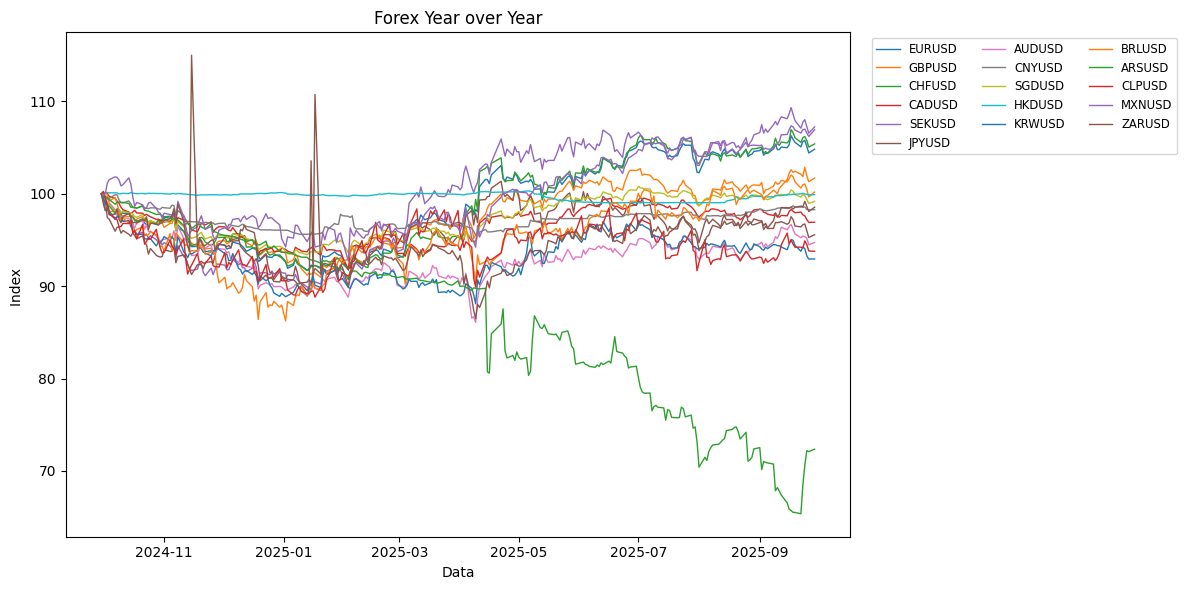

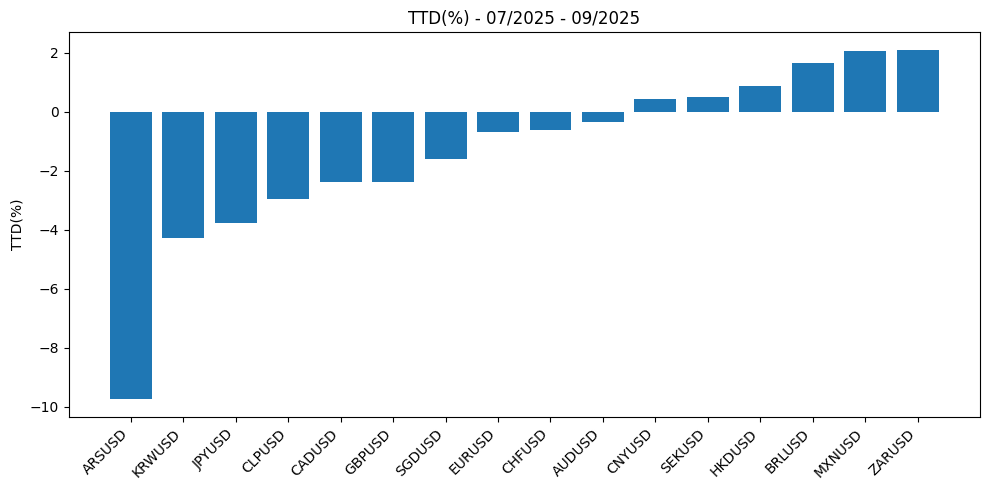

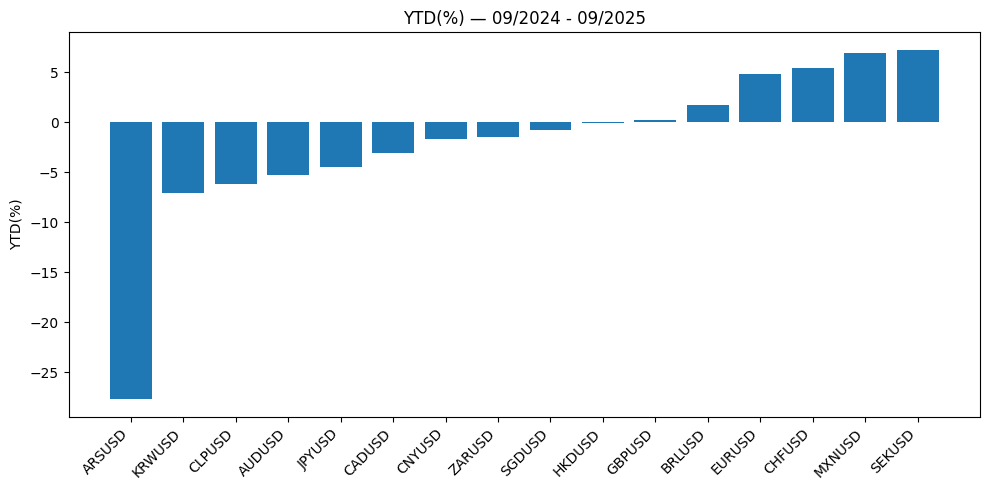

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from datetime import datetime
rcParams['figure.figsize']=15,6

pairs = [
    'EURUSD=X','GBPUSD=X','CHFUSD=X','CADUSD=X','SEKUSD=X',
    'JPYUSD=X','AUDUSD=X','CNYUSD=X','SGDUSD=X','HKDUSD=X',
    'KRWUSD=X','BRLUSD=X','ARSUSD=X','CLPUSD=X','MXNUSD=X',
    'ZARUSD=X'
]
# Períodos
monthly_months = ['2025-07', '2025-08', '2025-09']   
quarter_start = '2025-07-01'
quarter_end   = '2025-09-30'
yoy_ref_date = '2024-09-30'      
yoy_start = '2024-09-30'
yoy_end   = '2025-09-30'


print("Baixando dados (histórico para 2024-09-30 até 2025-09-30) — pode demorar...")
raw = yf.download(pairs, start=yoy_start, end=yoy_end, progress=True)


if isinstance(raw.columns, pd.MultiIndex):
    open_df  = raw['Open']
    high_df  = raw['High']
    low_df   = raw['Low']
    close_df = raw['Close']
else:
    open_df = raw['Open'] if 'Open' in raw.columns else pd.DataFrame()
    high_df = raw['High'] if 'High' in raw.columns else pd.DataFrame()
    low_df  = raw['Low']  if 'Low'  in raw.columns else pd.DataFrame()
    close_df= raw['Close']if 'Close' in raw.columns else pd.DataFrame()


def safe_first(series, start_date):
    s = series.loc[start_date:]
    s = s.dropna()
    return float(s.iloc[0]) if not s.empty else np.nan

def safe_last(series, end_date):
    s = series.loc[:end_date]
    s = s.dropna()
    return float(s.iloc[-1]) if not s.empty else np.nan

def try_download_single(ticker):
    try:
        sub = yf.download(ticker, start=yoy_start, end=yoy_end, progress=False)
        return sub
    except Exception:
        return None

monthly_rows = []
for pair in pairs:
    currency = pair.replace('=X','')
    for m in monthly_months:
        month_start = f"{m}-01"
        month_end = pd.to_datetime(month_start) + pd.offsets.MonthEnd(0)
        month_end_str = month_end.strftime('%Y-%m-%d')

        
        try:
            close_series = close_df[pair]
            open_series  = open_df[pair]
            high_series  = high_df[pair]
            low_series   = low_df[pair]
        except Exception:
            sub = try_download_single(pair)
            if sub is None or sub.empty:
                print(f"Warning: sem dados para {pair} no mês {m}.")
                monthly_rows.append({
                    'Currency': currency, 'Month': m,
                    'Open': np.nan, 'High': np.nan, 'Low': np.nan, 'Close': np.nan,
                    'Monthly_Var': np.nan, 'Monthly_Var_Pct': np.nan
                })
                continue
            close_series = sub['Close']
            open_series  = sub['Open']
            high_series  = sub['High']
            low_series   = sub['Low']

        open_v = safe_first(open_series, month_start)
        high_v = high_series.loc[month_start:month_end_str].max() if month_start in open_series.index.astype(str).tolist() or not high_series.loc[month_start:month_end_str].dropna().empty else (np.nan if pd.isna(open_v) else np.nan)

        try:
            high_v = float(high_series.loc[month_start:month_end_str].max())
        except Exception:
            high_v = np.nan
        try:
            low_v = float(low_series.loc[month_start:month_end_str].min())
        except Exception:
            low_v = np.nan
        close_v = safe_last(close_series, month_end_str)

        prev_end = (pd.to_datetime(month_start) - pd.offsets.MonthEnd(1)).strftime('%Y-%m-%d')
        prev_close = np.nan
        try:
            prev_close = safe_last(close_series, prev_end)
        except Exception:
            prev_close = np.nan

        monthly_var = (close_v - prev_close) if (not np.isnan(close_v) and not np.isnan(prev_close)) else np.nan
        monthly_var_pct = (monthly_var / prev_close * 100) if (not np.isnan(monthly_var) and prev_close not in (0, np.nan)) else np.nan

        monthly_rows.append({
            'Currency': currency,
            'Month': m,
            'Open': round(open_v,6) if not pd.isna(open_v) else np.nan,
            'High': round(high_v,6) if not pd.isna(high_v) else np.nan,
            'Low': round(low_v,6) if not pd.isna(low_v) else np.nan,
            'Close': round(close_v,6) if not pd.isna(close_v) else np.nan,
            'Monthly_Var': round(monthly_var,6) if not pd.isna(monthly_var) else np.nan,
            'Monthly_Var_Pct': round(monthly_var_pct,3) if not pd.isna(monthly_var_pct) else np.nan
        })

df_monthly = pd.DataFrame(monthly_rows)

quarter_rows = []
for pair in pairs:
    currency = pair.replace('=X','')
    try:
        open_series  = open_df[pair]
        high_series  = high_df[pair]
        low_series   = low_df[pair]
        close_series = close_df[pair]
    except Exception:
        sub = try_download_single(pair)
        if sub is None or sub.empty:
            print(f"Warning: sem dados trimestrais para {pair}.")
            quarter_rows.append({'Currency': currency,'OPEN':np.nan,'HIGH':np.nan,'LOW':np.nan,'CLOSE':np.nan})
            continue
        open_series = sub['Open']; high_series = sub['High']; low_series = sub['Low']; close_series = sub['Close']

    open_q = safe_first(open_series, quarter_start)
    try:
        high_q = float(high_series.loc[quarter_start:quarter_end].max())
    except Exception:
        high_q = np.nan
    try:
        low_q = float(low_series.loc[quarter_start:quarter_end].min())
    except Exception:
        low_q = np.nan
    close_q = safe_last(close_series, quarter_end)

    quarter_rows.append({'Currency': currency, 'OPEN':open_q, 'HIGH':high_q, 'LOW':low_q, 'CLOSE':close_q})

df_quarter = pd.DataFrame(quarter_rows).set_index('Currency')

yoy_rows = []
for pair in pairs:
    currency = pair.replace('=X','')
    try:
        close_series = close_df[pair]
    except Exception:
        sub = try_download_single(pair)
        if sub is None or sub.empty:
            print(f"Warning: sem dados YTD para {pair}.")
            yoy_rows.append({'Currency':currency,'Close_2024_09_30':np.nan,'Close_2025_09_30':np.nan})
            continue
        close_series = sub['Close']

    close_2024 = safe_last(close_series, '2024-09-30')
    close_2025 = safe_last(close_series, '2025-09-30')

    yoy_rows.append({
        'Currency': currency,
        'Close_2024_09_30': round(close_2024,6) if not pd.isna(close_2024) else np.nan,
        'Close_2025_09_30': round(close_2025,6) if not pd.isna(close_2025) else np.nan
    })

df_yoy = pd.DataFrame(yoy_rows).set_index('Currency')
df_summary = df_quarter.join(df_yoy)
df_summary['TTD'] = df_summary['CLOSE'] - df_summary['OPEN']
df_summary['TTD(%)'] = df_summary['TTD'] / df_summary['OPEN'] * 100
df_summary['YTD'] = df_summary['Close_2025_09_30'] - df_summary['Close_2024_09_30']
df_summary['YTD(%)'] = df_summary['YTD'] / df_summary['Close_2024_09_30'] * 100
df_summary = df_summary.round({'OPEN':6,'HIGH':6,'LOW':6,'CLOSE':6,'Close_2024_09_30':6,'Close_2025_09_30':6,'TTD':6,'TTD(%)':3,'YTD':6,'YTD(%)':3})


out_file = 'forex_jul_sep_2025_full_report.xlsx'
with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
    df_monthly.to_excel(writer, sheet_name='Monthly_by_month', index=False)
    df_summary.reset_index().to_excel(writer, sheet_name='Quarter_Summary', index=False)
    close_daily = close_df.loc['2024-09-30':'2025-09-30', pairs]
    close_daily.to_excel(writer, sheet_name='YoY_Close_Series')

print(f"Arquivo salvo: {out_file}")


plt.figure(figsize=(12,6))
for pair in pairs:
    try:
        series = close_df[pair].loc['2024-09-30':'2025-09-30'].dropna()
    except Exception:
        try:
            sub = try_download_single(pair)
            series = sub['Close'].loc['2024-09-30':'2025-09-30'].dropna() if sub is not None else pd.Series(dtype=float)
        except Exception:
            series = pd.Series(dtype=float)
    if series.empty:
        continue
    base = safe_last(series, '2024-09-30')
    if pd.isna(base) or base == 0:
        continue
    norm = series / base * 100
    plt.plot(norm.index, norm.values, label=pair.replace('=X',''), linewidth=1)

plt.title("Year over Year")
plt.xlabel("Data")
plt.ylabel("Index ")
plt.legend(ncol=3, fontsize='small', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
ttd_pct = df_summary['TTD(%)'].dropna().sort_values()
plt.bar(ttd_pct.index, ttd_pct.values)
plt.title("TTD(%) - 07/2025 - 09/2025")
plt.xticks(rotation=45, ha='right')
plt.ylabel('TTD(%)')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
ytd_pct = df_summary['YTD(%)'].dropna().sort_values()
plt.bar(ytd_pct.index, ytd_pct.values)
plt.title("YTD(%) — 09/2024 - 09/2025")
plt.xticks(rotation=45, ha='right')
plt.ylabel('YTD(%)')
plt.tight_layout()
plt.show()

In [ ]:
# investing_bonds_selenium.py
import time, re, requests, math
import pandas as pd
import numpy as np
from datetime import datetime
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
#from webdriver_manager.chrome import ChromeDriverManager

opts = Options()
driver = webdriver.Chrome(options=opts) 

bonds = ['US2Y','US5Y','US10Y','US20Y','JP10Y','DE10Y','CA10Y','FR10Y','GB10Y','BR10Y','IT10Y']

# Heurística de slugs (ajuste se algum slug mudar)
slug_map = {
    'US2Y':'/rates-bonds/u.s.-2-year-bond-yield-historical-data',
    'US5Y':'/rates-bonds/u.s.-5-year-bond-yield-historical-data',
    'US10Y':'/rates-bonds/u.s.-10-year-bond-yield-historical-data',
    'US20Y':'/rates-bonds/u.s.-20-year-bond-yield-historical-data',
    'JP10Y':'/rates-bonds/japan-10-year-bond-yield-historical-data',
    'DE10Y':'/rates-bonds/germany-10-year-bond-yield-historical-data',
    'CA10Y':'/rates-bonds/canada-10-year-bond-yield-historical-data',
    'FR10Y':'/rates-bonds/france-10-year-bond-yield-historical-data',
    'GB10Y':'/rates-bonds/united-kingdom-10-year-bond-yield-historical-data',
    'BR10Y':'/rates-bonds/brazil-10-year-bond-yield-historical-data',
    'IT10Y':'/rates-bonds/italy-10-year-bond-yield-historical-data',
}

# Períodos
quarter_start = '2025-10-01'
quarter_end   = '2026-01-08'
yoy_start_date = '2025-01-01'
yoy_end_date   = '2026-01-08'

# Endpoint histórico do Investing (ajax)
HIST_AJAX = "https://www.investing.com/instruments/HistoricalDataAjax"

# Controle de delays/retries
SLEEP_BETWEEN = 3.0
RETRY = 3

# ---------------- UTIL ----------------
def mmddyyyy(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    return dt.strftime("%m/%d/%Y")

def selenium_to_requests_cookies(driver, session):
    """Transfere cookies do Selenium para requests.Session()"""
    for c in driver.get_cookies():
        session.cookies.set(c['name'], c['value'], domain=c.get('domain'))
    return session

def extract_curr_id_from_page_source(source):
    # procura patterns comuns no HTML/JS
    m = re.search(r'curr_id["\']?\s*:\s*["\']?(\d{3,8})', source)
    if m:
        return m.group(1)
    m2 = re.search(r'pairId["\']?\s*:\s*["\']?(\d{3,8})', source)
    if m2:
        return m2.group(1)
    # procurar data-id attributes
    m3 = re.search(r'data-id=["\'](\d{3,8})["\']', source)
    if m3:
        return m3.group(1)
    return None

def fetch_historical_using_requests(curr_id, st, ed, session, referer):
    payload = {
        'curr_id': str(curr_id),
        'st_date': st,
        'end_date': ed,
        'interval_sec': 'Daily',
        'sort_col': 'date',
        'sort_ord': 'DESC',
        'action': 'historical_data'
    }
    headers = {
        "User-Agent": session.headers.get('User-Agent', 'Mozilla/5.0'),
        "Referer": referer,
        "X-Requested-With": "XMLHttpRequest",
        "Accept": "*/*",
    }
    resp = session.post(HIST_AJAX, data=payload, headers=headers, timeout=30)
    if resp.status_code != 200:
        # retorna DataFrame vazio para tratamento
        return pd.DataFrame(), resp.status_code, resp.text
    soup = BeautifulSoup(resp.text, 'html.parser')
    table = soup.find('table')
    if not table:
        return pd.DataFrame(), 200, resp.text
    headers_list = [th.get_text(strip=True).lower() for th in table.find_all('th')]
    rows = []
    for tr in table.find_all('tr')[1:]:
        cols = [td.get_text(strip=True).replace(',','') for td in tr.find_all('td')]
        if not cols:
            continue
        row = {}
        for i, h in enumerate(headers_list):
            row[h] = cols[i] if i < len(cols) else ''
        rows.append(row)
    if not rows:
        return pd.DataFrame(), 200, resp.text
    df = pd.DataFrame(rows)
    df.rename(columns=lambda x: x.strip().lower(), inplace=True)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for col in ['price','close','open','high','low','change %','change%','change']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace('%','').str.replace(',','')
            df[col] = pd.to_numeric(df[col], errors='coerce')
    if 'price' in df.columns and 'close' not in df.columns:
        df.rename(columns={'price':'close'}, inplace=True)
    for c in ('open','high','low','close'):
        if c not in df.columns:
            df[c] = np.nan
    df = df[['date','open','high','low','close']].sort_values('date').reset_index(drop=True)
    return df, 200, None

# ---------------- MAIN ----------------
def main(headless=False):
    # config selenium
    chrome_opts = Options()
    if headless:
        chrome_opts.add_argument("--headless=new")
    chrome_opts.add_argument("--no-sandbox")
    chrome_opts.add_argument("--disable-dev-shm-usage")
    chrome_opts.add_argument("--disable-gpu")
    chrome_opts.add_argument("--window-size=1600,900")
    # instantiate
    driver = webdriver.Chrome(ChromeDriverManager().install(), options=chrome_opts)

    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"})

    all_daily = {}
    meta = []

    for code in bonds:
        slug = slug_map.get(code)
        if not slug:
            print(f"[{code}] sem slug mapeado; pular")
            all_daily[code] = pd.DataFrame()
            continue
        url = f"https://www.investing.com{slug}"
        print(f"[{code}] abrindo: {url}")

        # abrir página no selenium (gera cookies e recursos JS)
        try:
            driver.get(url)
            time.sleep(2.0)  # aguardar carregamento
        except Exception as e:
            print("  Erro carregando página:", e)
            all_daily[code] = pd.DataFrame()
            continue

        # tentar fechar banner cookie / popups (se existirem)
        try:
            # procurar botões comuns; não é garantido, mas tentamos vários seletores
            for sel in [
                "//button[contains(., 'Accept') or contains(., 'I Accept') or contains(., 'Accept All')]",
                "//a[contains(., 'Accept') or contains(., 'I Accept')]",
                "//button[contains(@class,'agree')]", "//button[contains(@class,'accept')]"
            ]:
                els = driver.find_elements(By.XPATH, sel)
                if els:
                    try:
                        els[0].click()
                        time.sleep(0.5)
                        break
                    except:
                        pass
        except Exception:
            pass

        # extrair curr_id do HTML da página carregada
        source = driver.page_source
        curr_id = extract_curr_id_from_page_source(source)
        if curr_id:
            print("  curr_id extraído:", curr_id)
        else:
            print("  curr_id NÃO encontrado (tentaremos fallback).")

        # montar session requests com cookies do selenium
        session = selenium_to_requests_cookies(driver, session)

        # fallback: se curr_id não encontrado, tentar buscar em scripts via requests GET do URL e extrair
        if not curr_id:
            try:
                r = session.get(url, headers={"Referer":"https://www.investing.com"})
                curr_id = extract_curr_id_from_page_source(r.text)
                if curr_id:
                    print("  curr_id extraído via GET:", curr_id)
            except Exception:
                pass

        if not curr_id:
            print(f"  Não foi possível localizar curr_id para {code}; página mudou. Pulando.")
            all_daily[code] = pd.DataFrame()
            time.sleep(SLEEP_BETWEEN)
            continue

        # tentar chamar histórico via requests (usando cookies/headers do navegador)
        st = mmddyyyy(yoy_start_date)
        ed = mmddyyyy(yoy_end_date)
        df_hist = pd.DataFrame()
        last_status = None
        for attempt in range(RETRY):
            df_hist, status, text = fetch_historical_using_requests(curr_id, st, ed, session, referer=url)
            last_status = status
            if status == 200 and not df_hist.empty:
                break
            print(f"  tentativa {attempt+1} status {status}; retry em {SLEEP_BETWEEN*(attempt+1)}s")
            time.sleep(SLEEP_BETWEEN*(attempt+1))
        if df_hist.empty:
            print(f"  histórico vazio para {code} (último status {last_status}).")
        else:
            print(f"  histórico coletado: {len(df_hist)} linhas. intervalo: {df_hist['date'].min().date()} -> {df_hist['date'].max().date()}")
        all_daily[code] = df_hist
        meta.append({'code':code, 'curr_id':curr_id, 'url':url})
        time.sleep(SLEEP_BETWEEN)

    # fim loop
    driver.quit()

    qstart = pd.to_datetime(quarter_start)
    qend = pd.to_datetime(quarter_end)
    quarter_rows = []
    yoy_rows = []
    for code, df in all_daily.items():
        if df is None or df.empty:
            quarter_rows.append({'Bond':code,'OPEN':np.nan,'HIGH':np.nan,'LOW':np.nan,'CLOSE':np.nan})
            yoy_rows.append({'Bond':code,'Close_2024_09_30':np.nan,'Close_2025_09_30':np.nan})
            continue
        sel = df[(df['date'] >= qstart) & (df['date'] <= qend)].copy()
        if sel.empty:
            quarter_rows.append({'Bond':code,'OPEN':np.nan,'HIGH':np.nan,'LOW':np.nan,'CLOSE':np.nan})
        else:
            open_q = sel['open'].dropna().iloc[0] if not sel['open'].dropna().empty else np.nan
            high_q = sel['high'].max() if 'high' in sel.columns else np.nan
            low_q  = sel['low'].min() if 'low' in sel.columns else np.nan
            close_q= sel['close'].dropna().iloc[-1] if not sel['close'].dropna().empty else np.nan
            quarter_rows.append({'Bond':code,'OPEN':open_q,'HIGH':high_q,'LOW':low_q,'CLOSE':close_q})
        # Y/Y closes
        close_2024 = df[df['date'] <= pd.to_datetime('2024-09-30')]['close'].dropna()
        close_2025 = df[df['date'] <= pd.to_datetime('2025-09-30')]['close'].dropna()
        c2024 = float(close_2024.iloc[-1]) if not close_2024.empty else np.nan
        c2025 = float(close_2025.iloc[-1]) if not close_2025.empty else np.nan
        yoy_rows.append({'Bond':code,'Close_2024_09_30':c2024,'Close_2025_09_30':c2025})

    df_quarter = pd.DataFrame.from_records(quarter_rows).set_index('Bond')
    df_yoy = pd.DataFrame.from_records(yoy_rows).set_index('Bond')
    df_summary = df_quarter.join(df_yoy, how='outer')
    df_summary['TTD'] = df_summary['CLOSE'] - df_summary['OPEN']
    df_summary['TTD(%)'] = df_summary['TTD'] / df_summary['OPEN'] * 100
    df_summary['YTD'] = df_summary['Close_2025_09_30'] - df_summary['Close_2024_09_30']
    df_summary['YTD(%)'] = df_summary['YTD'] / df_summary['Close_2024_09_30'] * 100
    df_summary = df_summary.round(6)

    # salvar excel (abas)
    out_file = "investing_bonds_report_2025Q3_selenium.xlsx"
    with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
        df_summary.reset_index().to_excel(writer, sheet_name='Quarter_Summary', index=False)
        df_yoy.reset_index().to_excel(writer, sheet_name='YoY_Closes', index=False)
        for code, df in all_daily.items():
            try:
                sheet = f"{code}_daily"
                if df is None or df.empty:
                    pd.DataFrame().to_excel(writer, sheet_name=sheet, index=False)
                else:
                    df.to_excel(writer, sheet_name=sheet, index=False)
            except Exception as e:
                print("Erro ao salvar aba", sheet, e)
    print("Relatório salvo em:", out_file)

    # Plots: OPEN azul vs CLOSE vermelho (trimestre) & YTD closes
    import matplotlib.pyplot as plt
    plt.style.use('seaborn-whitegrid')

    plot_df = df_summary[['OPEN','CLOSE']].dropna(how='any').copy()
    if not plot_df.empty:
        labels = plot_df.index.tolist()
        x = np.arange(len(labels))
        w = 0.35
        plt.figure(figsize=(12,6))
        plt.bar(x - w/2, plot_df['OPEN'].values, width=w, color='tab:blue', label='OPEN (trimestre)')
        plt.bar(x + w/2, plot_df['CLOSE'].values, width=w, color='tab:red', label='CLOSE (trimestre)')
        plt.xticks(x, labels, rotation=45, ha='right')
        plt.title('OPEN vs CLOSE — 01/07/2025 a 30/09/2025')
        plt.ylabel('Yield (valor absoluto)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Sem dados completos para plot do trimestre.")

    plot_df2 = df_summary[['Close_2024_09_30','Close_2025_09_30']].dropna(how='any').copy()
    if not plot_df2.empty:
        labels = plot_df2.index.tolist()
        x = np.arange(len(labels))
        w = 0.35
        plt.figure(figsize=(12,6))
        plt.bar(x - w/2, plot_df2['Close_2024_09_30'].values, width=w, color='tab:blue', label='Close 2024-09-30')
        plt.bar(x + w/2, plot_df2['Close_2025_09_30'].values, width=w, color='tab:red', label='Close 2025-09-30')
        plt.xticks(x, labels, rotation=45, ha='right')
        plt.title('Fechamento 30/09/2024 vs 30/09/2025 — YTD')
        plt.ylabel('Yield (valor absoluto)')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Sem dados completos para plot YTD.")

if __name__ == "__main__":
    # Recomendo rodar sem headless no primeiro teste para ver o navegador em ação:
    main(headless=False)


NameError: name 'ChromeDriverManager' is not defined

In [10]:
import drive
from google.colab import drive 
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'